In [1]:
R.version

               _                                
platform       x86_64-w64-mingw32               
arch           x86_64                           
os             mingw32                          
crt            ucrt                             
system         x86_64, mingw32                  
status                                          
major          4                                
minor          5.2                              
year           2025                             
month          10                               
day            31                               
svn rev        88974                            
language       R                                
version.string R version 4.5.2 (2025-10-31 ucrt)
nickname       [Not] Part in a Rumble           

In [2]:
library("ape")
library("phytools")
library("nlme")

Loading required package: maps



In [7]:
primate_eyes <- read.csv("./primateEyes.csv", row.names = "Genus_species", stringsAsFactors = TRUE)
primate_tree <- ape::read.tree("./primateEyes.phy")

In [8]:
head(primate_eyes)

,Group,Skull_length,Optic_foramen_area,Orbit_area,Activity_pattern,Activity_pattern_code
,<fct>,<dbl>,<dbl>,<dbl>,<fct>,<int>
Allenopithecus_nigroviridis,Anthropoid,98.5,7.0,298.7,Diurnal,0
Alouatta_palliata,Anthropoid,109.8,5.3,382.3,Diurnal,0
Alouatta_seniculus,Anthropoid,108.0,8.0,359.4,Diurnal,0
Aotus_trivirgatus,Anthropoid,60.5,3.1,297.4,Nocturnal,2
Arctocebus_aureus,Prosimian,49.5,1.2,134.8,Nocturnal,2
Arctocebus_calabarensis,Prosimian,53.8,1.6,156.6,Nocturnal,2


In [9]:
species_list <- rownames(primate_eyes) # has underscores
corr <- ape::corBrownian(phy = primate_tree, form~species_list)
ancova <- nlme::gls(log(Orbit_area)~log(Skull_length)+Activity_pattern, data = primate_eyes, correlation = corr)
anova(ancova)

Warning message in Initialize.corPhyl(X[[i]], ...):
"No covariate specified, species will be taken as ordered in the data frame. To avoid this message, specify a covariate containing the species names with the 'form' argument."


,numDF,F-value,p-value
,<int>,<dbl>,<dbl>
(Intercept),1,608.32477,9.071644e-41
log(Skull_length),1,558.19332,2.288353e-39
Activity_pattern,2,30.41525,1.024079e-10


In [14]:
for (act in names(ptcolors)) print(act)

[1] "Cathemeral"
[1] "Diurnal"
[1] "Nocturnal"


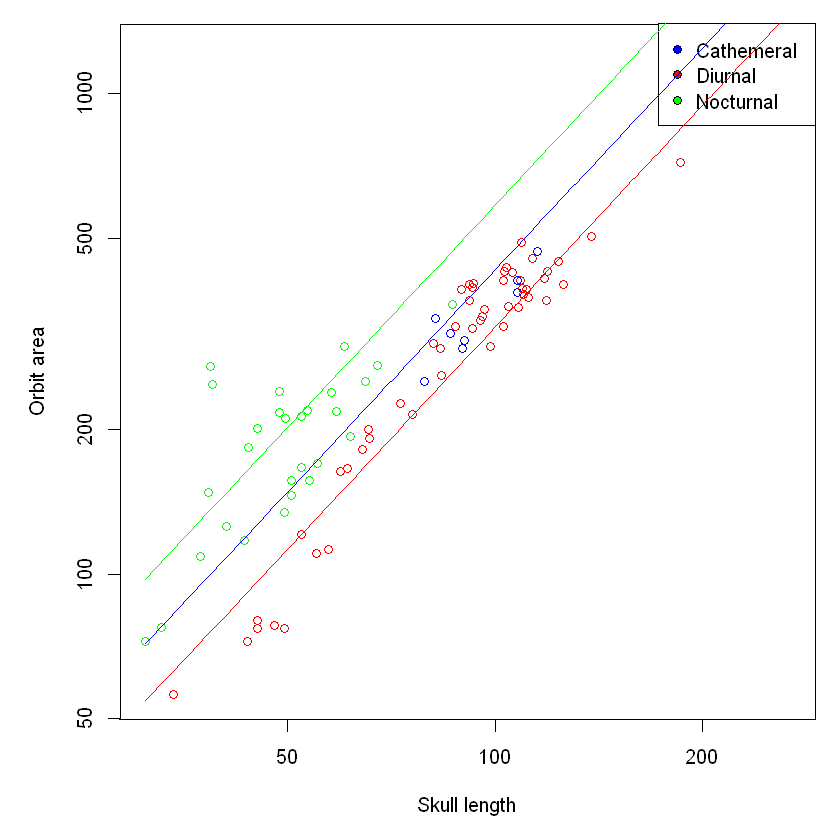

In [15]:
ptcolors <- setNames(c("blue", "red", "green"), nm = sort(unique(primate_eyes$Activity_pattern)))
dummy_x <- seq(min(primate_eyes$Skull_length), max(primate_eyes$Skull_length), length.out = 100)

par(mar=c(5, 5, 1, 1))
plot(y = primate_eyes$Orbit_area, x = primate_eyes$Skull_length, pch = 21, col = ptcolors[primate_eyes$Activity_pattern], log = "xy", ylab = "Orbit area", xlab = "Skull length")
legend("topright", legend = names(ptcolors), pt.bg = ptcolors, pch = 21)
for (act in sort(unique(primate_eyes$Activity_pattern))){
    lines(x = dummy_x, y = exp(predict(ancova, newdata = data.frame(Skull_length = dummy_x, Activity_pattern = rep(act, 100)))), col = ptcolors[act])    
}